In [1]:
import scanpy as sc
import muon as mu
import scirpy as ir
import seaborn
from scipy import stats
import matplotlib.pyplot as plt

2026-08-05 19:17:34.053414: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-05 19:17:34.100218: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
adata_m = sc.read_h5ad('./data/scrna_xenograft.h5ad')

/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


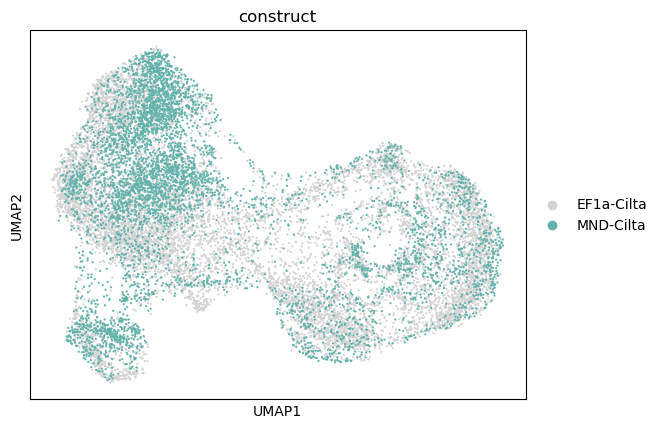

In [3]:
sc.pl.umap(adata_m, color='construct', palette=['#D3D3D3', '#63B3AC'], size=10)

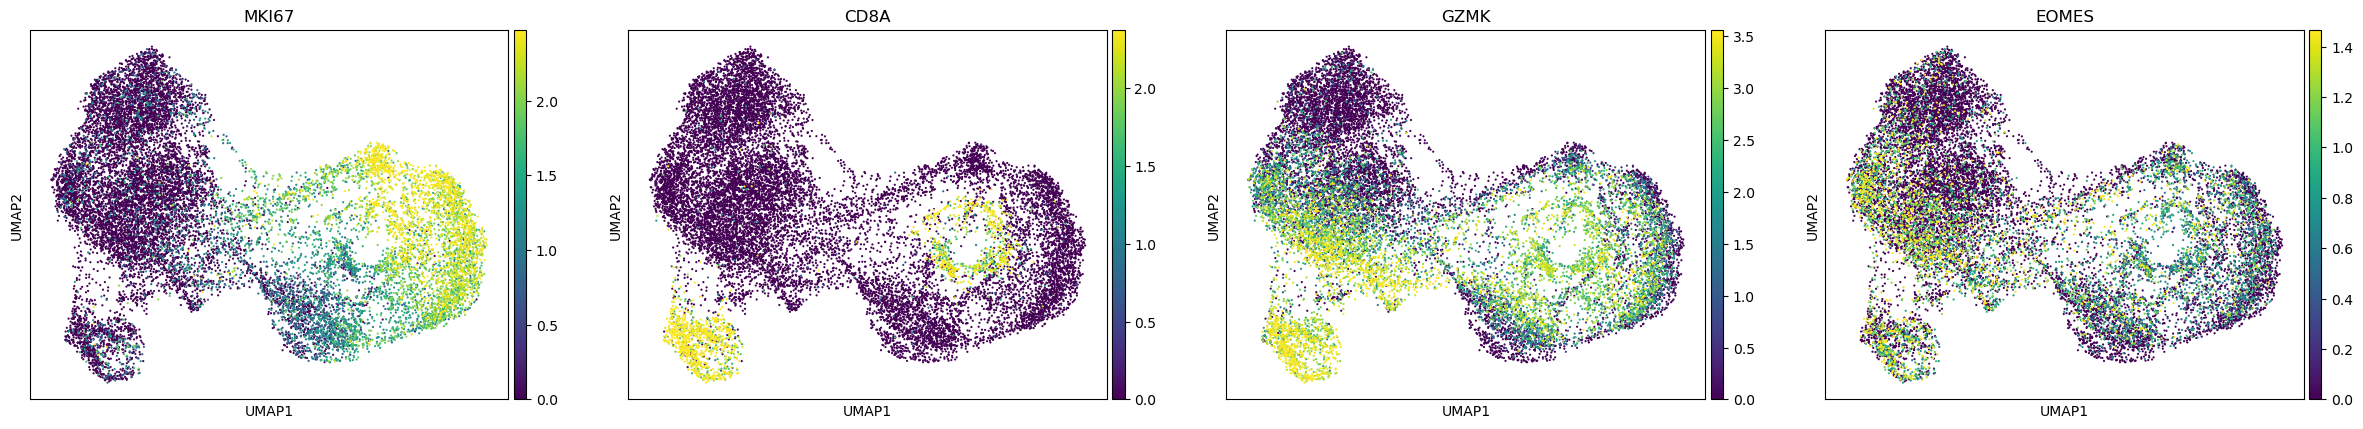

In [4]:
sc.pl.umap(adata_m, color=['MKI67', 'CD8A', 'GZMK', 'EOMES'], size=10, vmax='p95')

/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


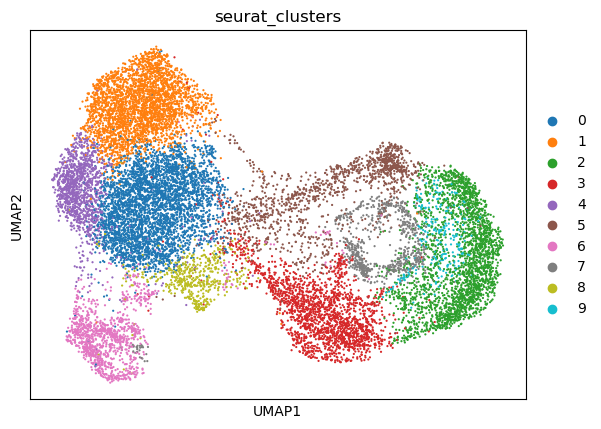

In [5]:
sc.pl.umap(adata_m, color='seurat_clusters', size=10)

In [6]:
genes = {'TFs': ['TCF7', 'LEF1', 'TBX21', 'EOMES', 'BACH2', 'PRDM1', 'TOX'],
         'Surface': ['CD27', 'CD28', 'IL7R', 'PDCD1', 'HAVCR2'],
         'Function': ['PRF1', 'GZMA', 'GZMB', 'GZMK', 'NKG7', 'GNLY', 'IFNG'],
         'Treg': ['FOXP3', 'IKZF2', 'CTLA4'],
         'Prolif': ['TOP2A', 'CDK1', 'MKI67']}

/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/data1/lesliec/sneha/anaconda/envs/scanpy-R-env/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', '

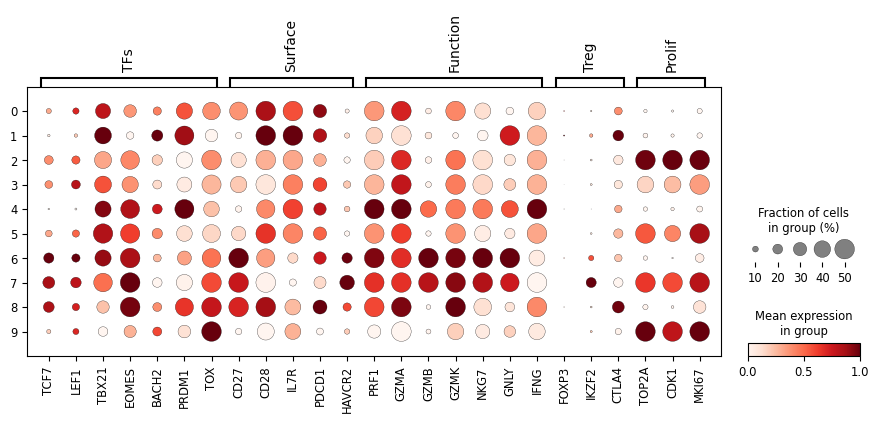

In [7]:
sc.pl.dotplot(adata_m, genes, groupby='seurat_clusters', dot_max=0.5, standard_scale='var')

In [8]:
ir.tl.alpha_diversity(adata_m, groupby="mouseID_construct")

EF1a-Cilta vs. MND-Cilta p-value: 0.17452534056858338


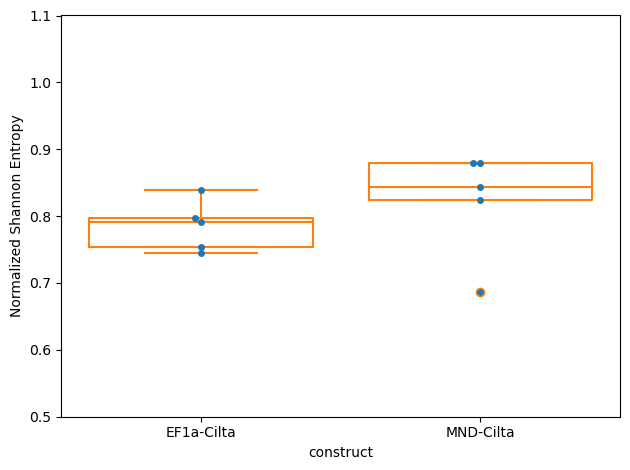

In [9]:
df = adata_m.obs.copy()
df['construct'] = df['construct'].values.tolist()
df['mouseID'] = df['mouseID'].values.tolist()
df['normalized_shannon_entropy_clone_id'] = df['normalized_shannon_entropy_clone_id'].values.tolist()
df = df[['construct', 'mouseID', 'normalized_shannon_entropy_clone_id']].groupby(['construct', 'mouseID']).mean().reset_index()
seaborn.swarmplot(data=df, x='construct', y='normalized_shannon_entropy_clone_id')
seaborn.boxplot(data=df, x='construct', y='normalized_shannon_entropy_clone_id', fill=None)
_, pv = stats.ranksums(df[df['construct']=='EF1a-Cilta']['normalized_shannon_entropy_clone_id'].values,
                       df[df['construct']=='MND-Cilta']['normalized_shannon_entropy_clone_id'].values)
print("EF1a-Cilta vs. MND-Cilta p-value:", pv)

plt.ylabel('Normalized Shannon Entropy')
plt.ylim((0.5,1.1))
plt.tight_layout()